In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


Using device: cuda
Classes:
0: Back
1: Blank-Tab
2: Close-Tab
3: Close-Window
4: Forward
5: Gmail
6: Refresh
7: Screenshot
8: Wordle
9: Youtube
Train samples: 800
Validation samples: 200
Epoch 001/100 | Train Loss: 2.3035 | Train Acc: 0.1000 | Val Loss: 2.2902 | Val Acc: 0.0714
Saved best model (val_acc=0.0714)
Epoch 002/100 | Train Loss: 2.2505 | Train Acc: 0.1087 | Val Loss: 2.1913 | Val Acc: 0.0714
Epoch 003/100 | Train Loss: 2.0469 | Train Acc: 0.2062 | Val Loss: 1.8045 | Val Acc: 0.2723
Saved best model (val_acc=0.2723)
Epoch 004/100 | Train Loss: 1.6749 | Train Acc: 0.3237 | Val Loss: 1.6019 | Val Acc: 0.2679
Epoch 005/100 | Train Loss: 1.4933 | Train Acc: 0.4100 | Val Loss: 1.4968 | Val Acc: 0.4107
Saved best model (val_acc=0.4107)
Epoch 006/100 | Train Loss: 1.3416 | Train Acc: 0.4713 | Val Loss: 1.3388 | Val Acc: 0.5223
Saved best model (val_acc=0.5223)
Epoch 007/100 | Train Loss: 1.2491 | Train Acc: 0.5300 | Val Loss: 1.2376 | Val Acc: 0.5625
Saved best model (val_acc=0.5625)

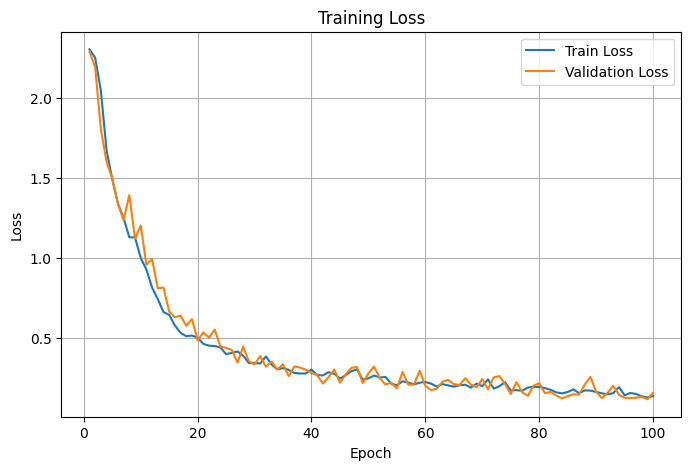

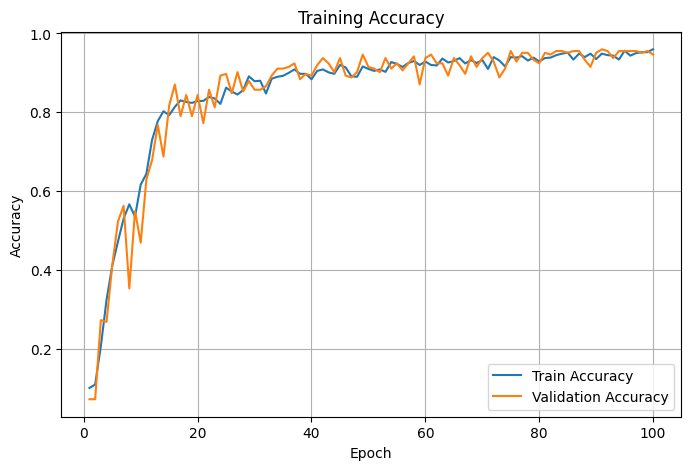

In [31]:
import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import numpy as np
from PIL import Image


# =====================================================
# CONFIG
# =====================================================

DATA_DIR = "Gesture-Data"  # Path to the directory containing gesture images

IMAGE_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 1e-3

MODEL_PATH = "gesture_cnn.pt"
CLASSES_PATH = "gesture_classes.json"

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Using device: {DEVICE}")


# =====================================================
# TRANSFORMS
# =====================================================

def crop_to_square_content(img, padding=50):
    img = np.array(img)

    # detect foreground (your logic: dark pixels)
    coords = np.column_stack(np.where(img < 100))

    if coords.size == 0:
        return Image.fromarray(img)

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    # add padding
    y_min = max(0, y_min - padding)
    x_min = max(0, x_min - padding)
    y_max = min(img.shape[0], y_max + padding)
    x_max = min(img.shape[1], x_max + padding)

    # bounding box size
    h = y_max - y_min
    w = x_max - x_min

    # make square side = max dimension
    side = max(h, w)

    # center the square on bbox center
    cy = (y_min + y_max) // 2
    cx = (x_min + x_max) // 2

    y1 = max(0, cy - side // 2)
    x1 = max(0, cx - side // 2)
    y2 = y1 + side
    x2 = x1 + side

    # fix if out of bounds (shift back into image)
    if y2 > img.shape[0]:
        y2 = img.shape[0]
        y1 = y2 - side
    if x2 > img.shape[1]:
        x2 = img.shape[1]
        x1 = x2 - side

    cropped = img[y1:y2, x1:x2]

    return Image.fromarray(cropped)

# img = Image.open("Gesture-Data/Back/Back_mouse_path_18.png").convert("L")  # grayscale

# cropped = crop_to_square_content(img)

# plt.figure(figsize=(6,3))

# plt.subplot(1,2,1)
# plt.title("Original")
# plt.imshow(img, cmap="gray")

# plt.subplot(1,2,2)
# plt.title("Cropped")
# plt.imshow(cropped, cmap="gray")

# plt.show()

train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Lambda(crop_to_square_content),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        fill=255
    ),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.9).float()),
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Lambda(crop_to_square_content),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.9).float())
])


# =====================================================
# DATASET
# =====================================================
class TransformDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return self.transform(x), y

# -----------------------
# Full dataset (NO transform here)
# -----------------------
full_dataset = datasets.ImageFolder(DATA_DIR)

class_names = full_dataset.classes

print("Classes:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

with open(CLASSES_PATH, "w") as f:
    json.dump(class_names, f)

# -----------------------
# Split indices
# -----------------------
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=generator
)

train_dataset = TransformDataset(train_subset, train_transform)
val_dataset = TransformDataset(val_subset, val_transform)

# -----------------------
# DataLoaders
# -----------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# import matplotlib.pyplot as plt

# for i in range(10):
#   images, labels = next(iter(train_loader))
#   plt.imshow(images[0][0], cmap="gray")
#   plt.title(labels[0])
#   plt.show()
# =====================================================
# MODEL
# =====================================================

class GestureCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = GestureCNN(
    len(class_names)
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# =====================================================
# HELPERS
# =====================================================

def compute_accuracy(outputs, labels):
    preds = outputs.argmax(dim=1)
    return (preds == labels).float().mean().item()


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


# =====================================================
# TRAINING
# =====================================================

best_model_state = copy.deepcopy(
    model.state_dict()
)

best_val_acc = 0.0

wrong_predictions = []

for epoch in range(EPOCHS):

    # -----------------------
    # TRAIN
    # -----------------------

    model.train()

    train_loss = 0.0
    train_acc = 0.0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()
        train_acc += compute_accuracy(
            outputs,
            labels
        )

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)

    # -----------------------
    # VALIDATION
    # -----------------------

    model.eval()

    val_loss = 0.0
    val_acc = 0.0

    wrong_predictions = []  # reset each epoch (or move outside if you want full history)

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            val_acc += compute_accuracy(
                outputs,
                labels
            )

            probs = F.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            # find wrong ones
            wrong_mask = preds != labels

            if wrong_mask.any():

                for i in wrong_mask.nonzero(as_tuple=True)[0]:

                    wrong_predictions.append({
                        "true_label": labels[i].item(),
                        "pred_label": preds[i].item(),
                        "logits": outputs[i].cpu().tolist(),
                        "probs": probs[i].cpu().tolist(),
                        "confidence": probs[i].max().item()
                    })

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            MODEL_PATH
        )

        with open("wrong_predictions.json", "w") as f:
            json.dump(wrong_predictions, f, indent=2)

        print(
            f"Saved best model "
            f"(val_acc={val_acc:.4f})"
        )


# =====================================================
# FINAL RESULTS
# =====================================================

print()
print("=" * 50)
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("=" * 50)

model.load_state_dict(best_model_state)


# =====================================================
# PLOTS
# =====================================================

epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)
plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    history["train_acc"],
    label="Train Accuracy"
)
plt.plot(
    epochs,
    history["val_acc"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()